**2 Análisis de componentes principales (PCA)**

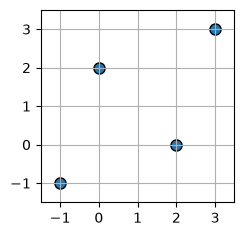

In [4]:
import matplotlib.pyplot as plt
import numpy as np

X = np.array([
    [-1, -1],
    [ 0,  2],
    [ 2,  0],
    [ 3,  3]
])
N = len(X)

fig, ax = plt.subplots(figsize=(2.5, 2.5))

plt.grid(True)
plt.axis([-1.5, 3.5, -1.5, 3.5])
plt.xticks(range(-1, 4))
plt.yticks(range(-1, 4))

plt.scatter(*X.T, facecolor='C0', edgecolor='k', s=64)
plt.show()

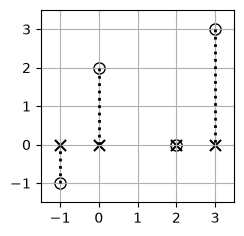

In [5]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np

# Model setup and projection
K = 1
W = np.array([1, 0]).reshape(-1, K)
Z = (X @ W).reshape(-1, K)
hX = Z @ W.T

# Figure initialization
fig, ax = plt.subplots(figsize=(2.5, 2.5))
plt.grid(True)
plt.axis([-1.5, 3.5, -1.5, 3.5])
plt.xticks(range(-1, 4))
plt.yticks(range(-1, 4))

# Scatter original and projected points
plt.scatter(*X.T, facecolor='white', edgecolor='k', s=64)
plt.scatter(*hX.T, facecolor='black', s=64, marker='x')

# Create dotted connection lines between points and projections
lines = np.zeros((N, 2, 2))
lines[:, 0, :] = X
lines[:, 1, :] = hX
lc = LineCollection(lines, linewidths=2, colors='black', linestyle='dotted')
ax.add_collection(lc)

plt.show()

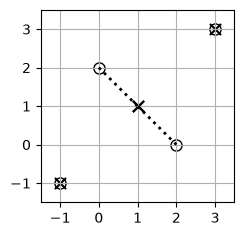

In [6]:
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np

# Projections onto the diagonal line (w = [1/√2, 1/√2])
K = 1
W = np.array([np.sqrt(2) / 2, np.sqrt(2) / 2]).reshape(-1, K)
Z = (X @ W).reshape(-1, K)
hX = Z @ W.T

# Figure setup
fig, ax = plt.subplots(figsize=(2.5, 2.5))
plt.grid(True)
plt.axis([-1.5, 3.5, -1.5, 3.5])
plt.xticks(range(-1, 4))
plt.yticks(range(-1, 4))

# Plot original points and projected points
plt.scatter(*X.T, facecolor='white', edgecolor='k', s=64)
plt.scatter(*hX.T, facecolor='black', s=64, marker='x')

# Draw dotted projection lines
lines = np.zeros((N, 2, 2))
lines[:, 0, :] = X
lines[:, 1, :] = hX
lc = LineCollection(lines, linewidths=2, colors='black', linestyle='dotted')
ax.add_collection(lc)

plt.show()

**3 PCA con la EVD**

In [7]:
import numpy as np

# Dataset
X = np.array([
    [-1, -1],
    [ 0,  2],
    [ 2,  0],
    [ 3,  3]
])

# Compute biased covariance matrix (divided by N instead of N - 1)
S = np.cov(X, rowvar=False, bias=True)
print(S)

[[2.5 1.5]
 [1.5 2.5]]


In [10]:
La, U = np.linalg.eigh(S); i = La.argsort()[::-1]
La = La[i]
U = U[:,i]
U

array([[ 0.70710678, -0.70710678],
       [ 0.70710678,  0.70710678]])

**4 PCA con la SVD**

In [11]:

import numpy as np 
X = np.array([ [-1, -1], [0, 2], [2, 0], [3, 3] ])
X = X - np.mean(X, axis=0)
_, _, Vt = np.linalg.svd(X) 
print(Vt)

[[ 0.70710678  0.70710678]
 [ 0.70710678 -0.70710678]]
